# Single input single objective

### this notebook is made to plot an example of Bayesian optimization using one input and one objective. 

Our current test device is however not able to handle one input at the time, so we made a test optimization with 2 inputs, the second one being fixed at `x2=4`

## add the main repository to the path

This is made for running the code while it has not been installed, it should be removed when the installer would work

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

## imports

In [2]:
# library
import matplotlib.pyplot as plt
import torch

# project
from laplace_opt.post_analysis.postAnalysis import PostAnalysis
from tests.test_function.target_function import target_function

## load the file

Indicate the folder and the file that correspond to the case you want to test.

This example is made for a 1 input dimension (1d), 1 objective (1o).

It has been made without noise and it's the example of a gaussian process that fit correctly

In [ ]:
folder = "data/1i_1o_not_noisy_working/"
file = "1d_1o_not_noisy_working.pt"

pa = PostAnalysis(path=folder + file)


            Date: 2026-06-03 17:56:45
            Observations: 37
            Inputs: 2
            Objectives: 1
            Initial observations: 8
            Repeats: 1
            Steps: 30
            Description: 
            


## get the initialization context

The way the post analysis works is to recreate the context as it was in a given step of the optimization.

The first step correspond to the initialization, after that each step correspondonds to the model suggestions

In [4]:
ctx_init = pa.get_context_at_step(step=1)  # you can also use "pa.get_initial_context()"

Context created.
Observation added: x=[3.7012863159179688, 4.0], y=[0.5470435619354248], shot_number=2
Observation added: x=[4.945160388946533, 4.0], y=[0.7210854887962341], shot_number=3
Observation added: x=[9.408039093017578, 4.0], y=[0.25326159596443176], shot_number=4
Observation added: x=[-0.5545055866241455, 4.0], y=[0.06985199451446533], shot_number=5
Observation added: x=[0.5793428421020508, 4.0], y=[0.231810063123703], shot_number=6
Observation added: x=[8.24510383605957, 4.0], y=[0.4822249710559845], shot_number=7
Observation added: x=[6.90499210357666, 4.0], y=[0.7330192923545837], shot_number=8
Observation added: x=[1.7705843448638916, 4.0], y=[1.1285794973373413], shot_number=9


In [5]:
print(f"Initial context shape: {ctx_init.X_physical.shape}")      # we can verify that the data as the same shape than the "Initial observations" from the metadata
print(f"Initial second dimension: {ctx_init.X_physical[:, 1]}")   # we can verify that the second input dimension is constant

Initial context shape: torch.Size([8, 2])
Initial second dimension: tensor([4., 4., 4., 4., 4., 4., 4., 4.], dtype=torch.float64)


## get the optimization steps

To get the points proposed by the optimization, we can create the context at the end of the optimization.

Then we can use `ctx_opt.X_obs` to get the input proposed by the optimization

In [6]:
ctx_opt = pa.get_context_at_step(step=None)  # None means all steps, you can also use "pa.get_final_context()"

Context created.
Observation added: x=[3.7012863159179688, 4.0], y=[0.5470435619354248], shot_number=2
Observation added: x=[4.945160388946533, 4.0], y=[0.7210854887962341], shot_number=3
Observation added: x=[9.408039093017578, 4.0], y=[0.25326159596443176], shot_number=4
Observation added: x=[-0.5545055866241455, 4.0], y=[0.06985199451446533], shot_number=5
Observation added: x=[0.5793428421020508, 4.0], y=[0.231810063123703], shot_number=6
Observation added: x=[8.24510383605957, 4.0], y=[0.4822249710559845], shot_number=7
Observation added: x=[6.90499210357666, 4.0], y=[0.7330192923545837], shot_number=8
Observation added: x=[1.7705843448638916, 4.0], y=[1.1285794973373413], shot_number=9
Observation added: x=[2.153867721557617, 4.0], y=[1.2002285718917847], shot_number=11
Observation added: x=[-2.0, 4.0], y=[0.04891318455338478], shot_number=13
Observation added: x=[2.03902006149292, 4.0], y=[1.2079411745071411], shot_number=15
Observation added: x=[5.910632133483887, 4.0], y=[0.79

In [7]:
print(f"Optimization shape: {ctx_opt.X_opt.shape}")  # we have 29 steps of optimization and one step of initialization, this is coherent with the metadata (30)

Optimization shape: torch.Size([29, 2])


## Target function

Since we are making a test, we can plot the theory.

To do so, we are sampling the test function that was used for this example.

In [8]:
bounds = ctx_opt.bounds

x1 = torch.linspace(bounds[0, 0], bounds[1, 0], 1000)
x2 = torch.linspace(bounds[0, 1], bounds[1, 1], 1)

X1, X2 = torch.meshgrid(x1, x2, indexing="ij")

obj = target_function(X1, X2)
obj1 = obj[:, :, 0]     # objective we optimized
obj2 = obj[:, :, 1]     # we did not optimize this objective

## plot without model

We can now plot our initialization and optimization points along with the theory.

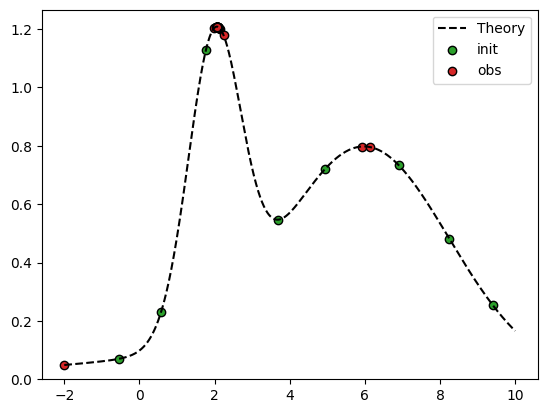

In [9]:
fig, ax1 = plt.subplots(1, 1)

# theory
ax1.plot(x1, obj1, label="Theory", color="k", ls="--")
ax1.set_ylim(0)

# init
ax1.scatter(ctx_init.X_physical[:, 0], ctx_init.Y_physical, label="init", color="tab:green", edgecolor="black")
ax1.legend()

# obs
ax1.scatter(ctx_opt.X_opt[:, 0], ctx_opt.Y_opt, label="obs", color="tab:red", edgecolor="black")
ax1.legend()

## plot model

To verify the model prediction, we might want to rebuild or recreate it and to add it on our previous plot.

This can be done using `pa.get_posterior(context, X_grid)`.

with `X_grid`, the input grid overwich we want to sample the model.

In our case, the model is technically 2d, with the second dimension being constat, this is why we need to stack our X1 and X2.

In [10]:
ctx = pa.get_final_context()  # this is the same context than ctx_opt but it's an example of "pa.get_final_context()"

Context created.
Observation added: x=[3.7012863159179688, 4.0], y=[0.5470435619354248], shot_number=2
Observation added: x=[4.945160388946533, 4.0], y=[0.7210854887962341], shot_number=3
Observation added: x=[9.408039093017578, 4.0], y=[0.25326159596443176], shot_number=4
Observation added: x=[-0.5545055866241455, 4.0], y=[0.06985199451446533], shot_number=5
Observation added: x=[0.5793428421020508, 4.0], y=[0.231810063123703], shot_number=6
Observation added: x=[8.24510383605957, 4.0], y=[0.4822249710559845], shot_number=7
Observation added: x=[6.90499210357666, 4.0], y=[0.7330192923545837], shot_number=8
Observation added: x=[1.7705843448638916, 4.0], y=[1.1285794973373413], shot_number=9
Observation added: x=[2.153867721557617, 4.0], y=[1.2002285718917847], shot_number=11
Observation added: x=[-2.0, 4.0], y=[0.04891318455338478], shot_number=13
Observation added: x=[2.03902006149292, 4.0], y=[1.2079411745071411], shot_number=15
Observation added: x=[5.910632133483887, 4.0], y=[0.79

In [11]:
X_grid = torch.stack([X1, X2], dim=-1)
X_grid = X_grid.squeeze(1)
post_dict, mean_dict, std_dict = pa.get_posterior(      # get_posterior is returning three dictionaries of posteriors, means and stds 
    ctx=ctx,                                            # the dictionary contains the relevant features for each objective
    x_physical=X_grid
)

# since we only have one objective we can simply play with it directly
mean = mean_dict["ElectronCharge"]
std = std_dict["ElectronCharge"]

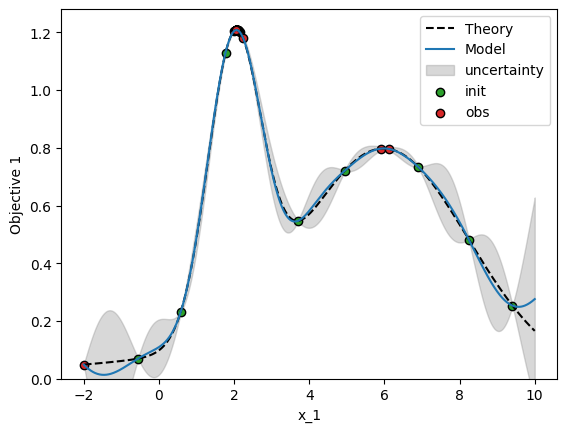

In [12]:
fig, ax1 = plt.subplots(1, 1)

# theory
ax1.plot(x1, obj1, label="Theory", color="k", ls="--")

# model
x_plot = X_grid[:, 0]
uppder_confidence = mean + 1.96 * std
lower_confidence = mean - 1.96 * std

ax1.plot(x_plot, mean, color="tab:blue", label="Model")

ax1.fill_between(
    x_plot, 
    uppder_confidence, 
    lower_confidence, 
    alpha=0.3,
    color="grey", 
    label="uncertainty"
)

# init
ax1.scatter(
    ctx_init.X_physical[:, 0], 
    ctx_init.Y_physical, 
    label="init", 
    color="tab:green", 
    edgecolor="black"
)

# obs
ax1.scatter(
    ctx_opt.X_opt[:, 0], 
    ctx_opt.Y_opt, 
    label="obs", 
    color="tab:red", 
    edgecolor="black"
)

ax1.set_ylim(0)
ax1.set_xlabel(r"x_1")
ax1.set_ylabel(r"Objective 1")
ax1.legend()


# Not working case

The Bayesian optimization might sometimes not converge as expected.

This case is shown as a not working case sharing the same condition 
as the previous one, but with less initialization and optimization
samples.

In [ ]:
folder = "data/1d_1o_not_noisy_not_working/"
file = "1i_1o_not_noisy_not_working.pt"

pa = PostAnalysis(path=folder + file)


            Date: 2026-06-04 16:33:31
            Observations: 23
            Inputs: 2
            Objectives: 1
            Initial observations: 4
            Repeats: 1
            Steps: 20
            Description: 
            


## get the observations

In [14]:
ctx_init = pa.get_initial_context()
ctx = pa.get_final_context()

Context created.
Observation added: x=[3.7012863159179688, 4.0], y=[0.5470435619354248], shot_number=2
Observation added: x=[4.945160388946533, 4.0], y=[0.7210854887962341], shot_number=3
Observation added: x=[9.408039093017578, 4.0], y=[0.25326159596443176], shot_number=4
Observation added: x=[-0.5545055866241455, 4.0], y=[0.06985199451446533], shot_number=5
Context created.
Observation added: x=[3.7012863159179688, 4.0], y=[0.5470435619354248], shot_number=2
Observation added: x=[4.945160388946533, 4.0], y=[0.7210854887962341], shot_number=3
Observation added: x=[9.408039093017578, 4.0], y=[0.25326159596443176], shot_number=4
Observation added: x=[-0.5545055866241455, 4.0], y=[0.06985199451446533], shot_number=5
Observation added: x=[5.958216667175293, 4.0], y=[0.797712504863739], shot_number=7
Observation added: x=[6.335119247436523, 4.0], y=[0.7876061797142029], shot_number=9
Observation added: x=[5.7788310050964355, 4.0], y=[0.7948444485664368], shot_number=11
Observation added: x

In [15]:
post_dict, mean_dict, std_dict = pa.get_posterior(      # get_posterior is returning three dictionaries of posteriors, means and stds 
    ctx=ctx,                                            # the dictionary contains the relevant features for each objective
    x_physical=X_grid
)

# # since we only have one objective we can simply play with it directly
mean = mean_dict["ElectronEnergyMean"]
std = std_dict["ElectronEnergyMean"]

## plot

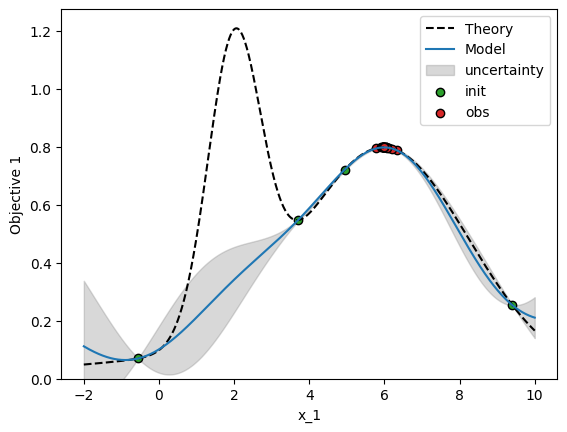

In [16]:
fig, ax1 = plt.subplots(1, 1)

# theory
ax1.plot(x1, obj1, label="Theory", color="k", ls="--")

# model
x_plot = X_grid[:, 0]
uppder_confidence = mean + 1.96 * std
lower_confidence = mean - 1.96 * std

ax1.plot(x_plot, mean, color="tab:blue", label="Model")

ax1.fill_between(
    x_plot, 
    uppder_confidence, 
    lower_confidence, 
    alpha=0.3,
    color="grey", 
    label="uncertainty"
)

# init
ax1.scatter(
    ctx_init.X_physical[:, 0], 
    ctx_init.Y_physical, 
    label="init", 
    color="tab:green", 
    edgecolor="black"
)

# obs
ax1.scatter(
    ctx.X_opt[:, 0], 
    ctx.Y_opt, 
    label="obs", 
    color="tab:red", 
    edgecolor="black"
)

ax1.set_ylim(0)
ax1.set_xlabel(r"x_1")
ax1.set_ylabel(r"Objective 1")
ax1.legend()
